# Fully synthetic blind validation challenge

This notebook performs a blind validation challenge using **only
synthetic data generated by this repository**.

The workflow is

\[
\text{hidden material}
\rightarrow
\text{public training observations}
\rightarrow
\text{blind calibration}
\rightarrow
\text{held-out predictions}
\rightarrow
\text{scoring against hidden targets}.
\]

Training and test protocols are disjoint. The calibration code sees
training observations and test deformation gradients, but does not
use test stresses or the hidden material parameters.

## Scientific status

This stage supports:

- computational verification;
- synthetic predictive validation;
- regression testing;
- uncertainty and robustness studies.

Its conclusions are restricted to the documented synthetic data-generating process.

In [1]:
from __future__ import annotations

import csv
import json
import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root.")


REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
SOURCE_DIRECTORY = REPOSITORY_ROOT / "src"
if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))

from anisotropic_remodeling import (
    MaterialParameterMap,
    create_synthetic_validation_challenge,
    evaluate_synthetic_challenge,
    fit_material_parameters,
    parametric_bootstrap_material_fit,
    perturb_synthetic_architecture,
    predict_dataset_stress,
)

np.set_printoptions(precision=6, suppress=True)

print(f"Repository root: {REPOSITORY_ROOT}")
print("External datasets used: none")

Repository root: D:\Anisotropic-Soft-Tissue-Remodeling
External datasets used: none


## 1. Create and lock the synthetic challenge

The generator creates a hidden two-family material, noisy training
observations, public test inputs, and hidden test targets.

The public calibration view contains:

- training deformation gradients and observed synthetic stress components;
- training noise standard deviations;
- known synthetic fiber directions and structural-order values;
- test deformation gradients and requested stress components;
- no test stresses;
- no hidden material parameters.

The hidden values remain inside the challenge object until the
scoring stage.

In [2]:
challenge = create_synthetic_validation_challenge(
    random_seed=202609,
    relative_noise=0.02,
    absolute_noise=0.004,
)
public = challenge.public

print(f"Challenge ID: {public.challenge_id}")
print(f"Data origin: {challenge.metadata['data_origin']}")
print(f"Training observations: {public.training_dataset.number_of_observations}")
print(f"Test observations: {public.number_of_test_observations}")
print(f"Training protocols: {public.training_protocols}")
print(f"Test protocols: {public.test_protocols}")
print(
    "Protocol overlap: "
    f"{set(public.training_protocols).intersection(public.test_protocols)}"
)

assert challenge.metadata["external_datasets_used"] == "none"
assert set(public.training_protocols).isdisjoint(public.test_protocols)

Challenge ID: ASTR-SYNTHETIC-CHALLENGE-01
Data origin: fully synthetic
Training observations: 42
Test observations: 36
Training protocols: ('train_uniaxial_x', 'train_uniaxial_y', 'train_simple_shear', 'train_dilation')
Test protocols: ('test_off_axis_extension', 'test_combined_extension_shear', 'test_axial_compression', 'test_transverse_shear')
Protocol overlap: set()


## 2. Inspect only the public training observations

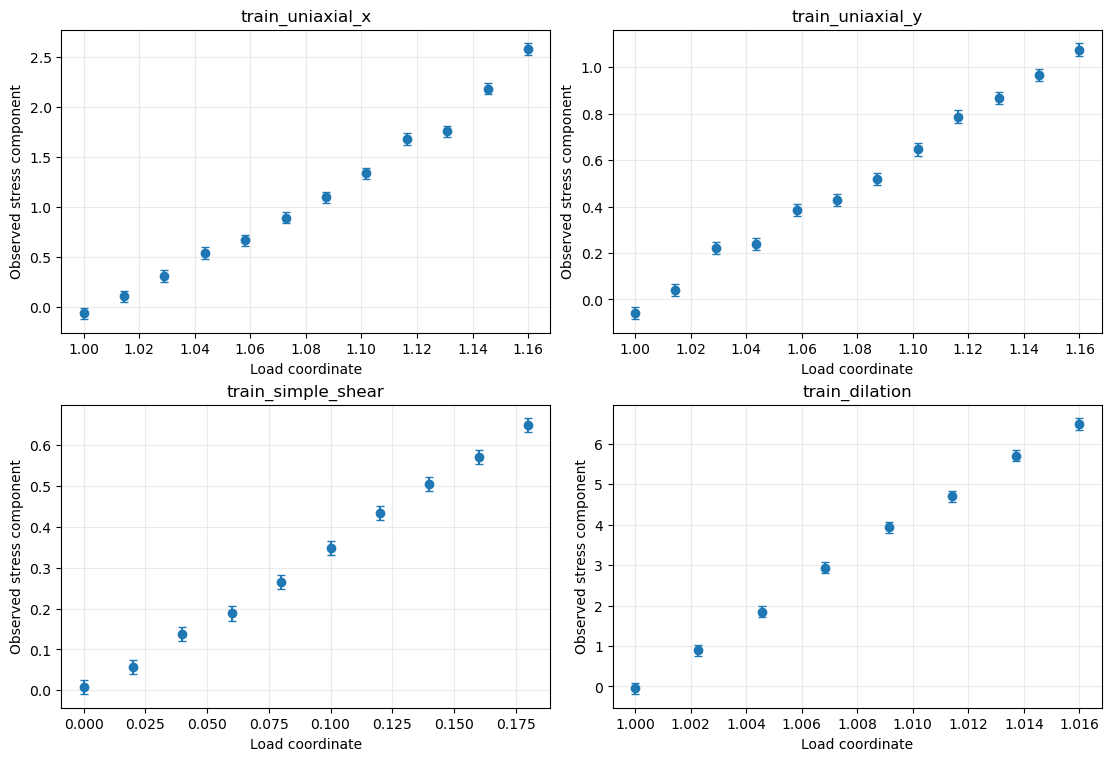

In [3]:
training = public.training_dataset

figure, axes = plt.subplots(2, 2, figsize=(11, 7.5), constrained_layout=True)
for axis, protocol in zip(axes.ravel(), training.protocols, strict=True):
    dataset = training.subset([protocol])
    axis.errorbar(
        dataset.load_value,
        dataset.observed_stress,
        yerr=dataset.noise_std,
        fmt="o",
        capsize=3,
    )
    axis.set(
        title=protocol,
        xlabel="Load coordinate",
        ylabel="Observed stress component",
    )
    axis.grid(True, alpha=0.25)
plt.show()

## 3. Blind calibration

The fitted positive parameter vector is

\[
\mathbf p=
(\mu,k_{11},k_{12},k_{21},k_{22},\kappa).
\]

Only the public training observations are supplied to the
optimizer. The hidden material and hidden test stresses are not
passed to the fitting function.

In [4]:
parameter_map = MaterialParameterMap(
    number_of_families=2,
    family_weights=public.family_weights,
    identify_kappa=True,
)

initial_values = np.array([2.0, 2.6, 2.0, 4.0, 3.8, 150.0])
lower_bounds = np.array([0.2, 0.2, 0.2, 0.5, 0.5, 20.0])
upper_bounds = np.array([8.0, 12.0, 12.0, 14.0, 14.0, 700.0])

fit = fit_material_parameters(
    public.training_dataset,
    public.fiber_direction,
    public.structural_order,
    parameter_map,
    initial_values=initial_values,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
)

print(f"Fit success: {fit.success}")
print(f"Optimizer message: {fit.message}")
print(f"Function evaluations: {fit.number_of_function_evaluations}")
print(f"Weighted objective: {fit.objective:.6f}")
print(f"Condition number: {fit.condition_number:.3e}")
print()
print(f"{'parameter':>12} {'blind estimate':>16} {'local std. error':>18}")
for name, estimate, standard_error in zip(
    fit.parameter_names,
    fit.parameter_vector,
    fit.standard_error,
    strict=True,
):
    print(f"{name:>12} {estimate:16.6f} {standard_error:18.6f}")

assert fit.success

Fit success: True
Optimizer message: `ftol` termination condition is satisfied.
Function evaluations: 11
Weighted objective: 33.429610
Condition number: 2.700e+02

   parameter   blind estimate   local std. error
          mu         2.499414           0.096897
        k1_1         3.800738           0.288073
        k1_2         2.082406           0.547622
        k2_1         3.437088           1.043382
        k2_2         1.033041           2.809231
       kappa       207.047409           2.528573


### 3.1 Training fit diagnostics

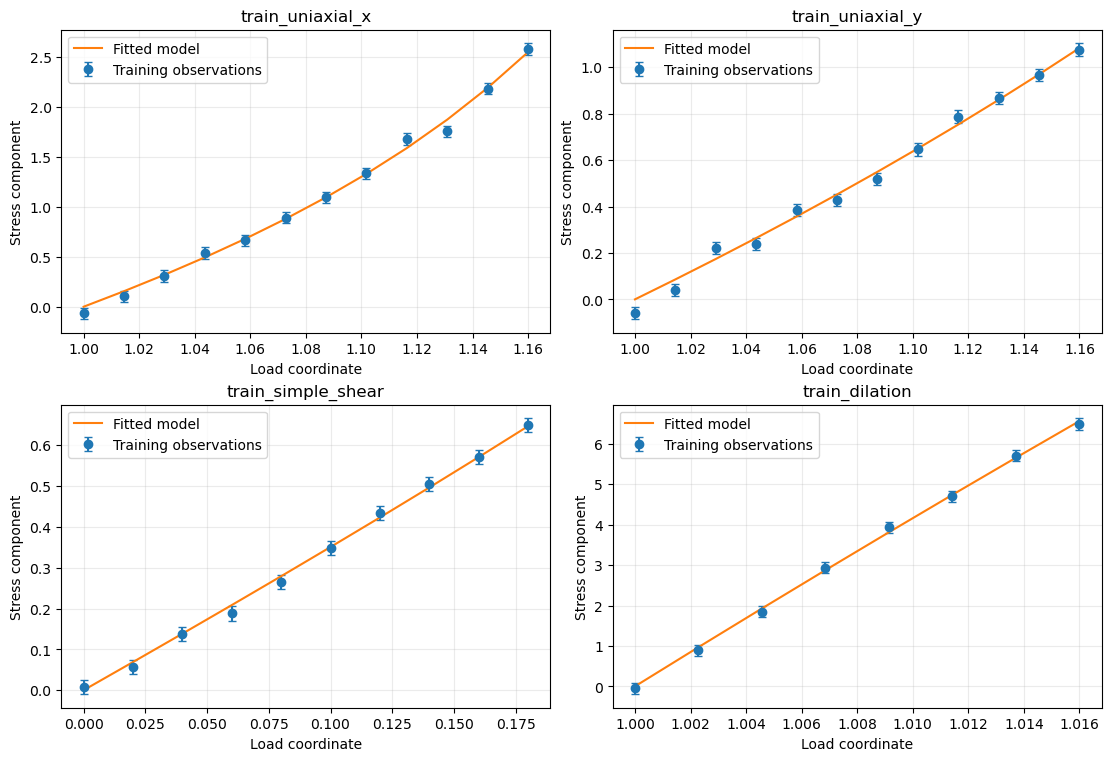

In [5]:
figure, axes = plt.subplots(2, 2, figsize=(11, 7.5), constrained_layout=True)

for axis, protocol in zip(axes.ravel(), training.protocols, strict=True):
    dataset = training.subset([protocol])
    prediction = predict_dataset_stress(
        dataset,
        public.fiber_direction,
        public.structural_order,
        fit.material,
    )
    order = np.argsort(dataset.load_value)
    axis.errorbar(
        dataset.load_value,
        dataset.observed_stress,
        yerr=dataset.noise_std,
        fmt="o",
        capsize=3,
        label="Training observations",
    )
    axis.plot(
        dataset.load_value[order],
        prediction[order],
        label="Fitted model",
    )
    axis.set(
        title=protocol,
        xlabel="Load coordinate",
        ylabel="Stress component",
    )
    axis.grid(True, alpha=0.25)
    axis.legend()

plt.show()

## 4. Predict the held-out protocols before revealing their targets

The test protocols are:

- off-axis extension;
- combined extension and shear;
- axial compression;
- transverse shear.

None appears in the training protocol list.

In [6]:
public_test_dataset = public.empty_test_dataset()

predicted_test_stress = predict_dataset_stress(
    public_test_dataset,
    public.fiber_direction,
    public.structural_order,
    fit.material,
)

print(f"Generated {predicted_test_stress.size} locked test predictions.")
print("The scoring function has not yet been called.")

Generated 36 locked test predictions.
The scoring function has not yet been called.


## 5. Unlock and score the hidden test targets

In [7]:
evaluation = evaluate_synthetic_challenge(
    challenge,
    predicted_test_stress,
)
clean_evaluation = evaluate_synthetic_challenge(
    challenge,
    predicted_test_stress,
    compare_to_clean_truth=True,
)

print("Overall score against noisy hidden observations")
print(f"  RMSE:                  {evaluation.overall.rmse:.6f}")
print(f"  MAE:                   {evaluation.overall.mae:.6f}")
print(f"  normalized RMSE:       {evaluation.overall.normalized_rmse:.3%}")
print(f"  R^2:                   {evaluation.overall.r_squared:.6f}")
print(f"  weighted RMSE:         {evaluation.overall.weighted_rmse:.6f}")
print(
    "  fraction within 2 sigma: "
    f"{evaluation.overall.fraction_within_two_sigma:.3%}"
)
print()
print("Score against the clean synthetic mean response")
print(f"  RMSE:            {clean_evaluation.overall.rmse:.6f}")
print(f"  normalized RMSE: {clean_evaluation.overall.normalized_rmse:.3%}")
print(f"  R^2:             {clean_evaluation.overall.r_squared:.6f}")

assert evaluation.overall.normalized_rmse < 0.04
assert evaluation.overall.r_squared > 0.97

Overall score against noisy hidden observations
  RMSE:                  0.071503
  MAE:                   0.046979
  normalized RMSE:       1.679%
  R^2:                   0.993655
  weighted RMSE:         1.639021
  fraction within 2 sigma: 77.778%

Score against the clean synthetic mean response
  RMSE:            0.061807
  normalized RMSE: 1.448%
  R^2:             0.995262


In [8]:
print(
    f"{'protocol':>34} {'RMSE':>12} {'nRMSE':>12} "
    f"{'R^2':>12} {'within 2 sigma':>16}"
)
for protocol, metric in evaluation.by_protocol.items():
    print(
        f"{protocol:>34} {metric.rmse:12.6f} "
        f"{metric.normalized_rmse:12.3%} "
        f"{metric.r_squared:12.6f} "
        f"{metric.fraction_within_two_sigma:16.3%}"
    )

                          protocol         RMSE        nRMSE          R^2   within 2 sigma
           test_off_axis_extension     0.116112       3.416%     0.988227          80.000%
     test_combined_extension_shear     0.058721       4.020%     0.982624          77.778%
            test_axial_compression     0.033724       5.455%     0.969445          75.000%
             test_transverse_shear     0.031809       3.390%     0.987203          77.778%


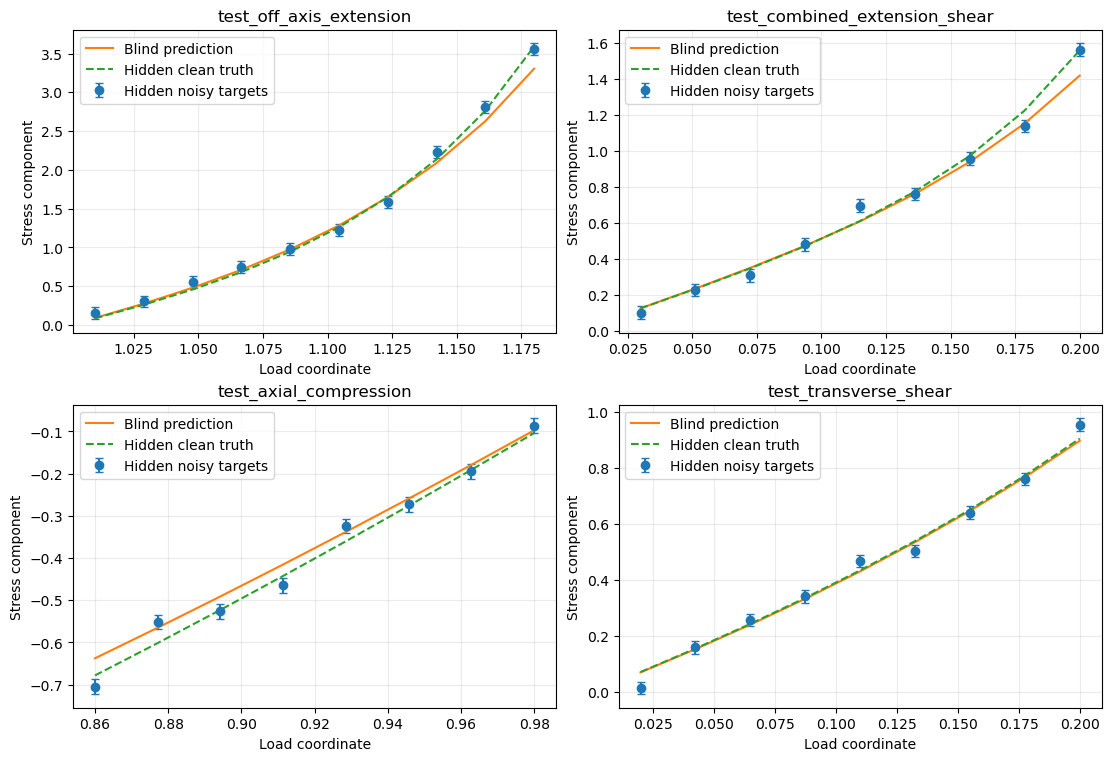

In [9]:
labels = np.asarray(public.test_protocol_name, dtype=object)
figure, axes = plt.subplots(2, 2, figsize=(11, 7.5), constrained_layout=True)

for axis, protocol in zip(axes.ravel(), public.test_protocols, strict=True):
    mask = labels == protocol
    order = np.argsort(public.test_load_value[mask])
    axis.errorbar(
        public.test_load_value[mask],
        challenge.hidden_test_stress_observed[mask],
        yerr=public.test_noise_std[mask],
        fmt="o",
        capsize=3,
        label="Hidden noisy targets",
    )
    axis.plot(
        public.test_load_value[mask][order],
        predicted_test_stress[mask][order],
        label="Blind prediction",
    )
    axis.plot(
        public.test_load_value[mask][order],
        challenge.hidden_test_stress_clean[mask][order],
        linestyle="--",
        label="Hidden clean truth",
    )
    axis.set(
        title=protocol,
        xlabel="Load coordinate",
        ylabel="Stress component",
    )
    axis.grid(True, alpha=0.25)
    axis.legend()

plt.show()

## 6. Reveal the hidden material only after prediction

Parameter recovery and predictive accuracy are different questions.
Strong test prediction can coexist with uncertain or correlated
parameter estimates.

In [10]:
hidden_parameters = parameter_map.pack(challenge.hidden_material)
relative_parameter_error = (
    fit.parameter_vector - hidden_parameters
) / hidden_parameters

print(
    f"{'parameter':>12} {'hidden truth':>14} {'estimate':>14} "
    f"{'relative error':>16}"
)
for name, truth, estimate, relative_error in zip(
    fit.parameter_names,
    hidden_parameters,
    fit.parameter_vector,
    relative_parameter_error,
    strict=True,
):
    print(
        f"{name:>12} {truth:14.6f} {estimate:14.6f} "
        f"{relative_error:16.3%}"
    )

   parameter   hidden truth       estimate   relative error
          mu       2.650000       2.499414          -5.682%
        k1_1       3.450000       3.800738          10.166%
        k1_2       1.550000       2.082406          34.349%
        k2_1       4.800000       3.437088         -28.394%
        k2_2       3.150000       1.033041         -67.205%
       kappa     210.000000     207.047409          -1.406%


## 7. Bootstrap parameter and predictive uncertainty

In [11]:
bootstrap = parametric_bootstrap_material_fit(
    public.training_dataset,
    public.fiber_direction,
    public.structural_order,
    parameter_map,
    fit,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
    number_of_samples=60,
    random_seed=202609,
)
bootstrap_samples = bootstrap.successful_samples
parameter_lower, parameter_upper = bootstrap.percentile_interval()

bootstrap_test_prediction = np.asarray(
    [
        predict_dataset_stress(
            public_test_dataset,
            public.fiber_direction,
            public.structural_order,
            parameter_map.unpack(sample),
        )
        for sample in bootstrap_samples
    ]
)
mean_lower, mean_upper = np.percentile(
    bootstrap_test_prediction,
    [2.5, 97.5],
    axis=0,
)

random_generator = np.random.default_rng(909)
noisy_predictive_samples = np.concatenate(
    [
        prediction[None, :]
        + random_generator.normal(
            0.0,
            public.test_noise_std,
            size=(20, public.number_of_test_observations),
        )
        for prediction in bootstrap_test_prediction
    ],
    axis=0,
)
predictive_lower, predictive_upper = np.percentile(
    noisy_predictive_samples,
    [2.5, 97.5],
    axis=0,
)

clean_mean_coverage = np.mean(
    (challenge.hidden_test_stress_clean >= mean_lower)
    & (challenge.hidden_test_stress_clean <= mean_upper)
)
noisy_predictive_coverage = np.mean(
    (challenge.hidden_test_stress_observed >= predictive_lower)
    & (challenge.hidden_test_stress_observed <= predictive_upper)
)

print(f"Successful bootstrap fits: {bootstrap_samples.shape[0]} / 60")
print(f"Clean mean-response coverage: {clean_mean_coverage:.3%}")
print(f"Noisy predictive coverage:    {noisy_predictive_coverage:.3%}")
assert bootstrap_samples.shape[0] == 60
assert clean_mean_coverage >= 0.90
assert noisy_predictive_coverage >= 0.75

Successful bootstrap fits: 60 / 60
Clean mean-response coverage: 100.000%
Noisy predictive coverage:    86.111%


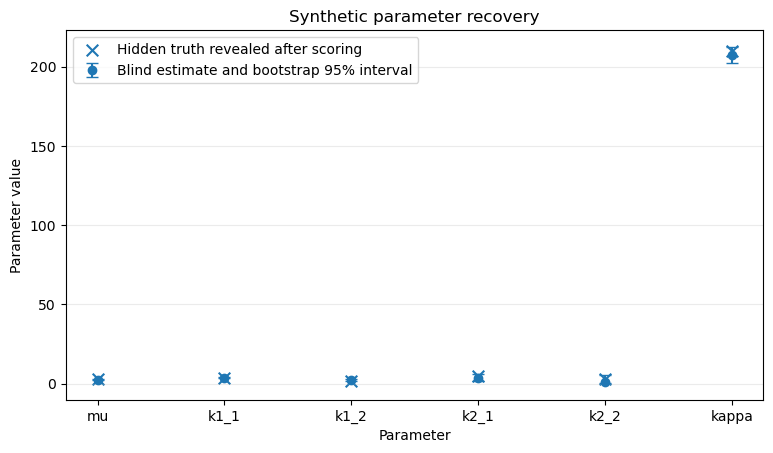

In [12]:
figure, axis = plt.subplots(figsize=(9, 4.8))
position = np.arange(parameter_map.size)
axis.errorbar(
    position,
    fit.parameter_vector,
    yerr=np.vstack(
        (
            fit.parameter_vector - parameter_lower,
            parameter_upper - fit.parameter_vector,
        )
    ),
    fmt="o",
    capsize=4,
    label="Blind estimate and bootstrap 95% interval",
)
axis.scatter(
    position,
    hidden_parameters,
    marker="x",
    s=70,
    label="Hidden truth revealed after scoring",
)
axis.set(
    xlabel="Parameter",
    ylabel="Parameter value",
    title="Synthetic parameter recovery",
    xticks=position,
    xticklabels=fit.parameter_names,
)
axis.grid(True, axis="y", alpha=0.25)
axis.legend()
plt.show()

## 8. Repeated challenge noise realizations

In [13]:
repeated_rows = []

for random_seed in range(202600, 202615):
    repeated_challenge = create_synthetic_validation_challenge(
        random_seed=random_seed,
        relative_noise=0.02,
        absolute_noise=0.004,
        challenge_id=f"ASTR-REPEAT-{random_seed}",
    )
    repeated_public = repeated_challenge.public
    repeated_fit = fit_material_parameters(
        repeated_public.training_dataset,
        repeated_public.fiber_direction,
        repeated_public.structural_order,
        parameter_map,
        initial_values=initial_values,
        lower_bounds=lower_bounds,
        upper_bounds=upper_bounds,
    )
    repeated_prediction = predict_dataset_stress(
        repeated_public.empty_test_dataset(),
        repeated_public.fiber_direction,
        repeated_public.structural_order,
        repeated_fit.material,
    )
    repeated_evaluation = evaluate_synthetic_challenge(
        repeated_challenge,
        repeated_prediction,
    )
    repeated_rows.append(
        (
            random_seed,
            repeated_evaluation.overall.rmse,
            repeated_evaluation.overall.normalized_rmse,
            repeated_evaluation.overall.r_squared,
            repeated_evaluation.overall.weighted_rmse,
        )
    )

repeated_array = np.asarray(repeated_rows, dtype=float)
print(
    "Held-out normalized RMSE across 15 noise realizations: "
    f"mean={np.mean(repeated_array[:, 2]):.3%}, "
    f"std={np.std(repeated_array[:, 2]):.3%}, "
    f"max={np.max(repeated_array[:, 2]):.3%}"
)
print(
    "Held-out R^2 across 15 noise realizations: "
    f"mean={np.mean(repeated_array[:, 3]):.6f}, "
    f"min={np.min(repeated_array[:, 3]):.6f}"
)

assert np.max(repeated_array[:, 2]) < 0.04
assert np.min(repeated_array[:, 3]) > 0.97

Held-out normalized RMSE across 15 noise realizations: mean=1.647%, std=0.601%, max=2.940%
Held-out R^2 across 15 noise realizations: mean=0.993045, min=0.981038


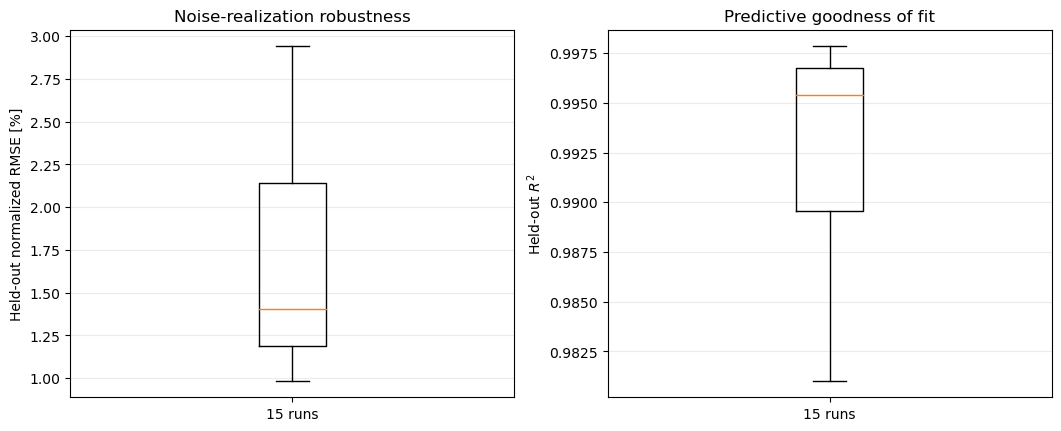

In [14]:
figure, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)

axes[0].boxplot(repeated_array[:, 2] * 100.0)
axes[0].set(
    ylabel="Held-out normalized RMSE [%]",
    title="Noise-realization robustness",
    xticks=[1],
    xticklabels=["15 runs"],
)
axes[0].grid(True, axis="y", alpha=0.25)

axes[1].boxplot(repeated_array[:, 3])
axes[1].set(
    ylabel=r"Held-out $R^2$",
    title="Predictive goodness of fit",
    xticks=[1],
    xticklabels=["15 runs"],
)
axes[1].grid(True, axis="y", alpha=0.25)

plt.show()

## 9. Synthetic architecture-reconstruction stress test

The primary challenge assumes that fiber directions and
structural-order values are known. To test this limitation, the
public architecture is perturbed before calibration.

Each uncertainty level is repeated for 20 independent synthetic
reconstruction errors. The reported statistic is the median
held-out normalized RMSE, with the 10th and 90th percentiles.

In [15]:
architecture_levels = [
    (0.0, 0.00),
    (2.0, 0.02),
    (5.0, 0.05),
    (8.0, 0.08),
]
architecture_rows = []

for angle_noise, order_noise in architecture_levels:
    level_metrics = []
    seeds = [0] if angle_noise == 0.0 else range(20)

    for random_seed in seeds:
        if angle_noise == 0.0:
            perturbed_fiber = public.fiber_direction
            perturbed_order = public.structural_order
        else:
            perturbed_fiber, perturbed_order = perturb_synthetic_architecture(
                public.fiber_direction,
                public.structural_order,
                angle_noise_std_deg=angle_noise,
                order_noise_std=order_noise,
                random_seed=random_seed,
            )

        perturbed_fit = fit_material_parameters(
            public.training_dataset,
            perturbed_fiber,
            perturbed_order,
            parameter_map,
            initial_values=initial_values,
            lower_bounds=lower_bounds,
            upper_bounds=upper_bounds,
        )
        perturbed_prediction = predict_dataset_stress(
            public_test_dataset,
            perturbed_fiber,
            perturbed_order,
            perturbed_fit.material,
        )
        perturbed_evaluation = evaluate_synthetic_challenge(
            challenge,
            perturbed_prediction,
        )
        level_metrics.append(
            perturbed_evaluation.overall.normalized_rmse
        )

    level_metrics = np.asarray(level_metrics)
    architecture_rows.append(
        (
            angle_noise,
            order_noise,
            float(np.median(level_metrics)),
            float(np.mean(level_metrics)),
            float(np.percentile(level_metrics, 10.0)),
            float(np.percentile(level_metrics, 90.0)),
        )
    )

architecture_array = np.asarray(architecture_rows)

print(
    f"{'angle std [deg]':>16} {'beta std':>10} {'median nRMSE':>15} "
    f"{'mean nRMSE':>14} {'P10':>10} {'P90':>10}"
)
for row in architecture_rows:
    print(
        f"{row[0]:16.2f} {row[1]:10.3f} {row[2]:15.3%} "
        f"{row[3]:14.3%} {row[4]:10.3%} {row[5]:10.3%}"
    )

assert np.all(np.diff(architecture_array[:, 2]) > 0.0)

 angle std [deg]   beta std    median nRMSE     mean nRMSE        P10        P90
            0.00      0.000          1.679%         1.679%     1.679%     1.679%
            2.00      0.020          3.093%         3.277%     1.440%     5.830%
            5.00      0.050          5.802%         9.586%     1.520%    16.335%
            8.00      0.080          7.814%        13.965%     1.655%    25.022%


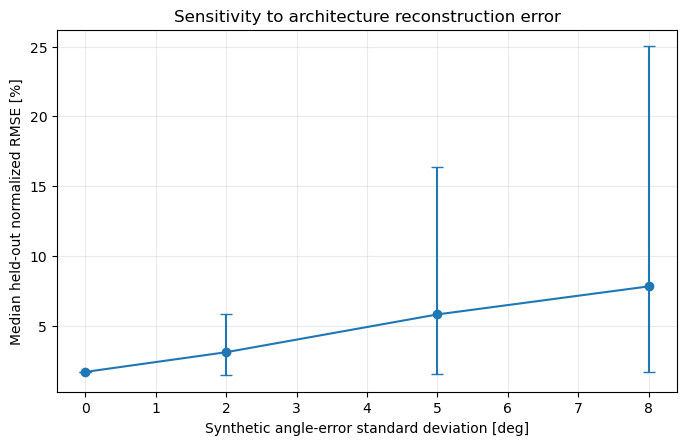

In [16]:
figure, axis = plt.subplots(figsize=(8, 4.7))
median = architecture_array[:, 2] * 100.0
lower = (architecture_array[:, 2] - architecture_array[:, 4]) * 100.0
upper = (architecture_array[:, 5] - architecture_array[:, 2]) * 100.0

axis.errorbar(
    architecture_array[:, 0],
    median,
    yerr=np.vstack((lower, upper)),
    marker="o",
    capsize=4,
)
axis.set(
    xlabel="Synthetic angle-error standard deviation [deg]",
    ylabel="Median held-out normalized RMSE [%]",
    title="Sensitivity to architecture reconstruction error",
)
axis.grid(True, alpha=0.25)
plt.show()

## 10. Export the public challenge and reference report

In [17]:
challenge_root = (
    REPOSITORY_ROOT
    / "data"
    / "synthetic"
    / "validation_challenge_01"
)
public_directory = challenge_root / "public"
reference_directory = challenge_root / "reference"
result_data = REPOSITORY_ROOT / "results" / "data"
result_figures = REPOSITORY_ROOT / "results" / "figures"

for directory in (
    public_directory,
    reference_directory,
    result_data,
    result_figures,
):
    directory.mkdir(parents=True, exist_ok=True)

manifest_path = public_directory / "challenge_manifest.json"
manifest = dict(challenge.metadata)
manifest.update(
    {
        "repository": (
            "https://github.com/Data-Driven-Biomedicine-Lab/"
            "Anisotropic-Soft-Tissue-Remodeling"
        ),
        "author": "Karina Urazova",
        "version": "0.9.0",
        "training_protocols": list(public.training_protocols),
        "test_protocols": list(public.test_protocols),
        "test_targets_public": False,
        "scientific_status": (
            "synthetic computational validation; "
            "not experimental validation"
        ),
    }
)
manifest_path.write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)

training_path = public_directory / "training_observations.csv"
with training_path.open("w", newline="", encoding="utf-8") as stream:
    writer = csv.writer(stream)
    writer.writerow(
        [
            "protocol",
            "load_value",
            "F_11",
            "F_12",
            "F_21",
            "F_22",
            "stress_row",
            "stress_column",
            "observed_stress",
            "noise_std",
        ]
    )
    for index in range(training.number_of_observations):
        writer.writerow(
            [
                training.protocol_name[index],
                training.load_value[index],
                *training.deformation_gradient[index].ravel(),
                *training.stress_component[index],
                training.observed_stress[index],
                training.noise_std[index],
            ]
        )

test_inputs_path = public_directory / "test_inputs.csv"
with test_inputs_path.open("w", newline="", encoding="utf-8") as stream:
    writer = csv.writer(stream)
    writer.writerow(
        [
            "protocol",
            "load_value",
            "F_11",
            "F_12",
            "F_21",
            "F_22",
            "stress_row",
            "stress_column",
            "noise_std",
        ]
    )
    for index in range(public.number_of_test_observations):
        writer.writerow(
            [
                public.test_protocol_name[index],
                public.test_load_value[index],
                *public.test_deformation_gradient[index].ravel(),
                *public.test_stress_component[index],
                public.test_noise_std[index],
            ]
        )

reference_path = reference_directory / "hidden_test_targets.csv"
with reference_path.open("w", newline="", encoding="utf-8") as stream:
    writer = csv.writer(stream)
    writer.writerow(
        [
            "protocol",
            "load_value",
            "clean_stress",
            "noisy_observed_stress",
            "blind_prediction",
        ]
    )
    for index in range(public.number_of_test_observations):
        writer.writerow(
            [
                public.test_protocol_name[index],
                public.test_load_value[index],
                challenge.hidden_test_stress_clean[index],
                challenge.hidden_test_stress_observed[index],
                predicted_test_stress[index],
            ]
        )

estimate_path = result_data / "synthetic_validation_parameter_estimates.csv"
with estimate_path.open("w", newline="", encoding="utf-8") as stream:
    writer = csv.writer(stream)
    writer.writerow(
        [
            "parameter",
            "hidden_truth",
            "blind_estimate",
            "local_standard_error",
            "bootstrap_lower_95",
            "bootstrap_upper_95",
        ]
    )
    for row in zip(
        fit.parameter_names,
        hidden_parameters,
        fit.parameter_vector,
        fit.standard_error,
        parameter_lower,
        parameter_upper,
        strict=True,
    ):
        writer.writerow(row)

metrics_path = result_data / "synthetic_validation_metrics.csv"
with metrics_path.open("w", newline="", encoding="utf-8") as stream:
    writer = csv.writer(stream)
    writer.writerow(
        [
            "scope",
            "rmse",
            "mae",
            "normalized_rmse",
            "r_squared",
            "weighted_rmse",
            "fraction_within_two_sigma",
            "maximum_absolute_error",
            "number_of_observations",
        ]
    )
    writer.writerow(["overall", *asdict(evaluation.overall).values()])
    for protocol, metric in evaluation.by_protocol.items():
        writer.writerow([protocol, *asdict(metric).values()])

repeated_path = result_data / "synthetic_validation_repeated_runs.csv"
np.savetxt(
    repeated_path,
    repeated_array,
    delimiter=",",
    header=(
        "random_seed,rmse,normalized_rmse,r_squared,weighted_rmse"
    ),
    comments="",
)

architecture_path = (
    result_data
    / "synthetic_validation_architecture_stress_test.csv"
)
np.savetxt(
    architecture_path,
    architecture_array,
    delimiter=",",
    header=(
        "angle_noise_std_deg,order_noise_std,median_normalized_rmse,"
        "mean_normalized_rmse,p10_normalized_rmse,p90_normalized_rmse"
    ),
    comments="",
)

uncertainty_path = (
    result_data
    / "synthetic_validation_uncertainty.npz"
)
np.savez_compressed(
    uncertainty_path,
    parameter_names=np.asarray(fit.parameter_names),
    bootstrap_parameter_samples=bootstrap_samples,
    bootstrap_test_prediction=bootstrap_test_prediction,
    mean_lower=mean_lower,
    mean_upper=mean_upper,
    predictive_lower=predictive_lower,
    predictive_upper=predictive_upper,
)

summary_path = (
    result_figures
    / "synthetic_validation_challenge_summary.png"
)
figure, axes = plt.subplots(
    2,
    2,
    figsize=(11, 7.5),
    constrained_layout=True,
)

axes[0, 0].scatter(
    challenge.hidden_test_stress_observed,
    predicted_test_stress,
)
minimum = min(
    np.min(challenge.hidden_test_stress_observed),
    np.min(predicted_test_stress),
)
maximum = max(
    np.max(challenge.hidden_test_stress_observed),
    np.max(predicted_test_stress),
)
axes[0, 0].plot([minimum, maximum], [minimum, maximum], linestyle="--")
axes[0, 0].set(
    xlabel="Hidden observed stress",
    ylabel="Blind predicted stress",
    title=rf"Held-out prediction, $R^2={evaluation.overall.r_squared:.3f}$",
)
axes[0, 0].grid(True, alpha=0.25)

axes[0, 1].errorbar(
    np.arange(parameter_map.size),
    fit.parameter_vector,
    yerr=np.vstack(
        (
            fit.parameter_vector - parameter_lower,
            parameter_upper - fit.parameter_vector,
        )
    ),
    fmt="o",
    capsize=4,
)
axes[0, 1].scatter(
    np.arange(parameter_map.size),
    hidden_parameters,
    marker="x",
    s=70,
)
axes[0, 1].set(
    title="Parameter recovery",
    xticks=np.arange(parameter_map.size),
    xticklabels=fit.parameter_names,
    ylabel="Parameter value",
)
axes[0, 1].grid(True, axis="y", alpha=0.25)

axes[1, 0].boxplot(repeated_array[:, 2] * 100.0)
axes[1, 0].set(
    title="15 noise realizations",
    ylabel="Held-out normalized RMSE [%]",
    xticks=[1],
    xticklabels=["Repeated challenge"],
)
axes[1, 0].grid(True, axis="y", alpha=0.25)

axes[1, 1].errorbar(
    architecture_array[:, 0],
    architecture_array[:, 2] * 100.0,
    yerr=np.vstack(
        (
            (
                architecture_array[:, 2]
                - architecture_array[:, 4]
            )
            * 100.0,
            (
                architecture_array[:, 5]
                - architecture_array[:, 2]
            )
            * 100.0,
        )
    ),
    marker="o",
    capsize=4,
)
axes[1, 1].set(
    title="Architecture uncertainty",
    xlabel="Angle-error std. [deg]",
    ylabel="Median held-out nRMSE [%]",
)
axes[1, 1].grid(True, alpha=0.25)

figure.savefig(summary_path, dpi=180)
plt.close(figure)

print(f"Saved: {manifest_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {training_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {test_inputs_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {reference_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {estimate_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {metrics_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {repeated_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {architecture_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {uncertainty_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {summary_path.relative_to(REPOSITORY_ROOT)}")

Saved: data\synthetic\validation_challenge_01\public\challenge_manifest.json
Saved: data\synthetic\validation_challenge_01\public\training_observations.csv
Saved: data\synthetic\validation_challenge_01\public\test_inputs.csv
Saved: data\synthetic\validation_challenge_01\reference\hidden_test_targets.csv
Saved: results\data\synthetic_validation_parameter_estimates.csv
Saved: results\data\synthetic_validation_metrics.csv
Saved: results\data\synthetic_validation_repeated_runs.csv
Saved: results\data\synthetic_validation_architecture_stress_test.csv
Saved: results\data\synthetic_validation_uncertainty.npz
Saved: results\figures\synthetic_validation_challenge_summary.png


## 11. Final validation checks

In [18]:
checks = {
    "fully synthetic provenance": (
        challenge.metadata["data_origin"] == "fully synthetic"
        and challenge.metadata["external_datasets_used"] == "none"
    ),
    "disjoint train and test protocols": set(
        public.training_protocols
    ).isdisjoint(public.test_protocols),
    "blind optimizer converged": fit.success,
    "held-out normalized RMSE below 4%": (
        evaluation.overall.normalized_rmse < 0.04
    ),
    "held-out R^2 above 0.97": (
        evaluation.overall.r_squared > 0.97
    ),
    "all bootstrap fits succeeded": (
        bootstrap_samples.shape[0] == 60
    ),
    "clean mean covered by parameter interval": (
        clean_mean_coverage >= 0.90
    ),
    "predictive coverage above 75%": (
        noisy_predictive_coverage >= 0.75
    ),
    "all repeated challenges meet threshold": (
        np.max(repeated_array[:, 2]) < 0.04
        and np.min(repeated_array[:, 3]) > 0.97
    ),
    "architecture error worsens median prediction": (
        np.all(np.diff(architecture_array[:, 2]) > 0.0)
    ),
}

for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'} — {name}")
assert all(checks.values())

PASS — fully synthetic provenance
PASS — disjoint train and test protocols
PASS — blind optimizer converged
PASS — held-out normalized RMSE below 4%
PASS — held-out R^2 above 0.97
PASS — all bootstrap fits succeeded
PASS — clean mean covered by parameter interval
PASS — predictive coverage above 75%
PASS — all repeated challenges meet threshold
PASS — architecture error worsens median prediction


## Interpretation

The model generalizes from the public training protocols to four held-out
loading paths inside the controlled synthetic system. The repeated-seed
analysis shows that this conclusion is not tied to one noise realization.

The architecture stress test is equally important: predictive error rises as
synthetic errors in fiber angle and structural order grow. Constitutive
calibration can compensate for part of this error, but it cannot remove the
loss of structural information.

## Scope statement

The release conclusion is:

> The software passed its fully synthetic blind validation challenge and
> associated robustness tests.